# Visualization Quality Metrics: *Benchmark Data*

This notebook computes Trustworthiness, Continuity, Spearman Correlation, and DEMaP for each dimensionality reduction method (PCA, UMAP, PHATE, PaCMAP) on a given benchmark dataset.

Embeddings and reduced embeddings are loaded from precomputed `.npy` files generated by `eval_pipeline.py`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from scipy.stats import spearmanr

# navigate to src/ from wherever the notebook is run
current = os.path.abspath('.')
while os.path.basename(current) != 'src' and current != os.path.dirname(current):
    current = os.path.dirname(current)
src_dir = current
os.chdir(src_dir)
sys.path.insert(0, src_dir)

In [2]:
# config: change dataset and embedding model here
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
dataset = "rcv1"  # options: rcv1, arxiv, amazon, dbpedia, wos

embedding_dir = f"{embedding_model}_embeddings"
reduction_dir = f"{embedding_model}_reduced_embeddings"
results_dir = f"{embedding_model}_results"
os.makedirs(results_dir, exist_ok=True)

## 1. Setup

Change `dataset` to run on a different benchmark. Available options: `rcv1`, `arxiv`, `amazon`, `dbpedia`, `wos`.

In [3]:
# load precomputed high-dimensional embeddings
x_high = np.load(f"{embedding_dir}/{dataset}.npy")
print(f"Embeddings shape: {x_high.shape}")

Embeddings shape: (1566, 384)


## 2. Load Embeddings

Load precomputed embeddings from `eval_pipeline.py` output. To generate these, run:

```bash
python src/run_models/benchmark_datasets/eval_pipeline.py --dataset rcv1
```

In [4]:
# load precomputed reduced embeddings from eval_pipeline.py
reductions = {
    "PCA":    np.load(f"{reduction_dir}/PCA_{dataset}.npy"),
    "UMAP":   np.load(f"{reduction_dir}/UMAP_{dataset}.npy"),
    "PHATE":  np.load(f"{reduction_dir}/PHATE_{dataset}.npy"),
    "PaCMAP": np.load(f"{reduction_dir}/PaCMAP_{dataset}.npy"),
}

for name, arr in reductions.items():
    print(f"{name}: {arr.shape}")

PCA: (1566, 300)
UMAP: (1566, 300)
PHATE: (1566, 300)
PaCMAP: (1566, 100)


In [5]:
def compute_continuity(x_high, x_low, n_neighbors=15):
    n = x_high.shape[0]
    
    d_high = pairwise_distances(x_high)
    d_low = pairwise_distances(x_low)
    rank_low = np.argsort(np.argsort(d_low, axis=1), axis=1)
    
    continuity = 0.0
    for i in range(n):
        neighbors_high = set(np.argsort(d_high[i])[1:n_neighbors+1])
        neighbors_low = set(np.argsort(d_low[i])[1:n_neighbors+1])
        missing = neighbors_high - neighbors_low
        for j in missing:
            continuity += rank_low[i, j] - n_neighbors
    
    norm = 2.0 / (n * n_neighbors * (2 * n - 3 * n_neighbors - 1))
    return 1 - norm * continuity

In [6]:
def compute_demap(x_high, x_low_2d, n_neighbors=5):
    # DEMaP: geodesic distances (k-NN shortest path) in high-dim vs Euclidean in 2D
    # Moon et al. 2019 (PHATE paper), k=5 to emphasize local structure
    knn = kneighbors_graph(x_high, n_neighbors=n_neighbors, mode='distance', include_self=False)
    geo = shortest_path(knn, directed=False)

    # replace inf (disconnected pairs) with 1 + max finite distance
    # treats disconnected pairs as maximally far rather than dropping them
    max_finite = np.nanmax(geo[np.isfinite(geo)])
    geo[np.isinf(geo)] = 1 + max_finite

    idx = np.triu_indices(x_high.shape[0], k=1)
    geo_flat = geo[idx]
    euc_flat = pairwise_distances(x_low_2d)[idx]

    return spearmanr(geo_flat, euc_flat)[0]

## 3. Metrics

- **Trustworthiness**: measures whether neighbors in low-dim space were also neighbors in high-dim space (local structure preservation)
- **Continuity**: measures whether neighbors in high-dim space are preserved in low-dim space (reverse of trustworthiness)
- **Spearman Correlation**: rank correlation of raw pairwise Euclidean distances high-dim vs 2D
- **DEMaP** (Moon et al. 2019): Spearman correlation of geodesic distances (k-NN shortest paths) in high-dim vs Euclidean distances in 2D; better captures true manifold structure than raw Euclidean

All scores range from 0 to 1, higher is better. Scores near 0.5 are expected for text embeddings. Projecting from 384 dimensions down to 2D loses most of the neighborhood structure regardless of which method is used.

In [7]:
stats = []

# subsample for large datasets to avoid memory issues (pairwise distances scale as n^2)
max_samples = 5000
if x_high.shape[0] > max_samples:
    np.random.seed(42)
    idx = np.random.choice(x_high.shape[0], max_samples, replace=False)
    x_high_sub = x_high[idx]
    reductions_sub = {name: arr[idx] for name, arr in reductions.items()}
    print(f"Subsampled to {max_samples} points for metrics computation")
else:
    x_high_sub = x_high
    reductions_sub = reductions

for name, x_low in reductions_sub.items():
    # use first 2 dimensions for metrics (methods have varying n_components)
    x_low_2d = x_low[:, :2] if x_low.ndim > 1 and x_low.shape[1] > 2 else x_low

    t_score = trustworthiness(x_high_sub, x_low_2d, n_neighbors=15)
    c_score = compute_continuity(x_high_sub, x_low_2d, n_neighbors=15)

    # spearman correlation of raw pairwise Euclidean distances
    d_high = pairwise_distances(x_high_sub).flatten()
    d_low  = pairwise_distances(x_low_2d).flatten()
    spearman_corr, _ = spearmanr(d_high, d_low)

    # DEMaP: geodesic distances in high-dim vs Euclidean in 2D (Moon et al. 2019)
    # k=5 for local structure, inf replaced with 1+max distance
    print(f"  Computing DEMaP for {name}...")
    demap_score = compute_demap(x_high_sub, x_low_2d, n_neighbors=5)

    stats.append({
        "Method": name,
        "Trustworthiness": round(t_score, 4),
        "Continuity": round(c_score, 4),
        "Spearman Correlation": round(spearman_corr, 4),
        "DEMaP": round(demap_score, 4)
    })
    print(f"{name}: Trustworthiness={t_score:.4f}, Continuity={c_score:.4f}, Spearman={spearman_corr:.4f}, DEMaP={demap_score:.4f}")

pd.DataFrame(stats)

  Computing DEMaP for PCA...
PCA: Trustworthiness=0.5010, Continuity=0.5071, Spearman=0.0065, DEMaP=-0.0018
  Computing DEMaP for UMAP...
UMAP: Trustworthiness=0.5039, Continuity=0.5077, Spearman=0.0148, DEMaP=-0.0010
  Computing DEMaP for PHATE...
PHATE: Trustworthiness=0.5010, Continuity=0.5046, Spearman=0.0125, DEMaP=-0.0020
  Computing DEMaP for PaCMAP...
PaCMAP: Trustworthiness=0.5021, Continuity=0.5038, Spearman=0.0095, DEMaP=-0.0053


,Method,Trustworthiness,Continuity,Spearman Correlation,DEMaP
0,PCA,0.5010,0.5071,0.0065,-0.0018
1,UMAP,0.5039,0.5077,0.0148,-0.0010
2,PHATE,0.5010,0.5046,0.0125,-0.0020
3,PaCMAP,0.5021,0.5038,0.0095,-0.0053


In [8]:
output_path = os.path.join(results_dir, f"viz_metrics_{dataset}.csv")
pd.DataFrame(stats).to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to sentence-transformers/all-MiniLM-L6-v2_results/viz_metrics_rcv1.csv


## 4. Shepard Diagrams

Compares pairwise distances in the original high-dimensional space against the reduced space. Points close to the red diagonal indicate better global distance preservation.

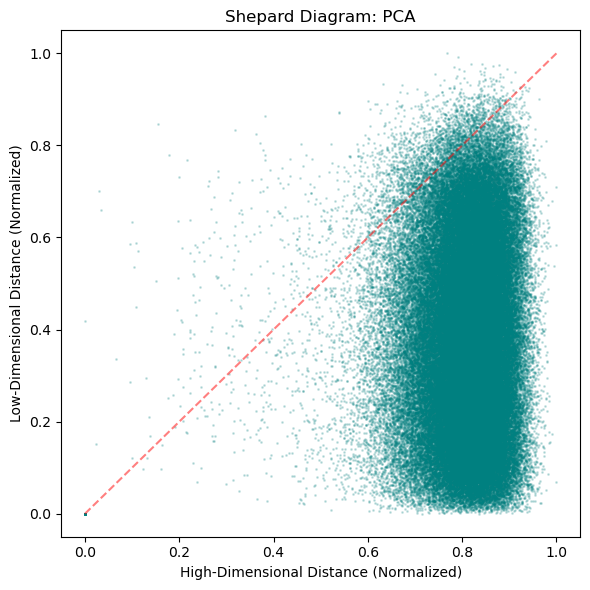

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_pca.png


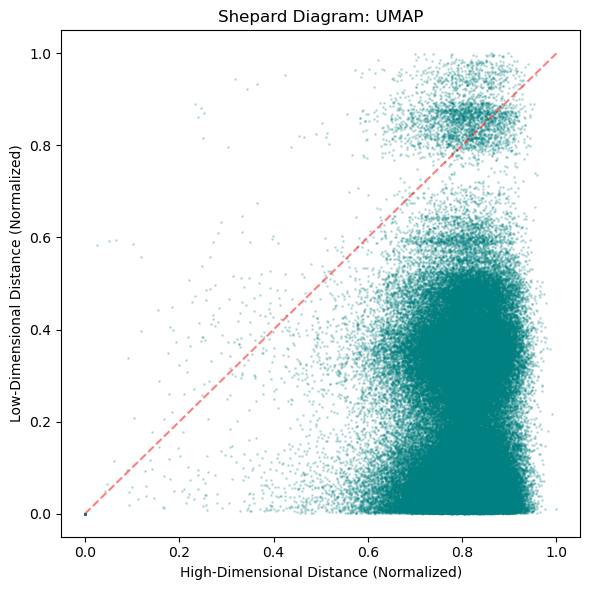

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_umap.png


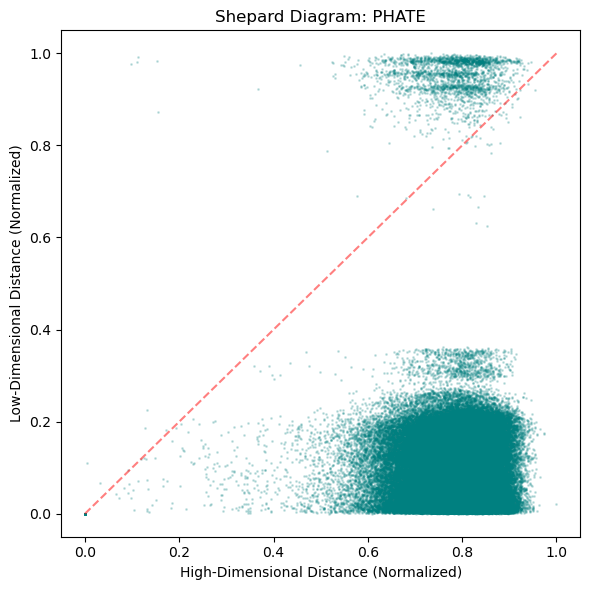

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_phate.png


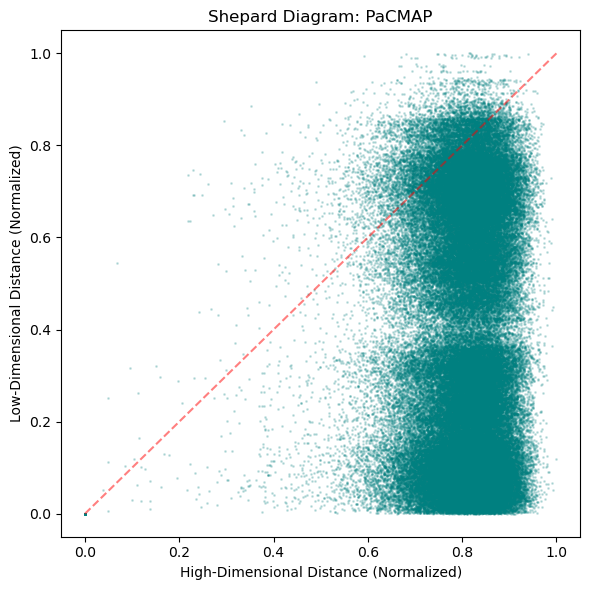

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_pacmap.png


In [9]:
def plot_shepard(x_high, x_low, name, sample_size=500):
    indices = np.random.choice(len(x_high), sample_size, replace=False)
    
    d_high = pairwise_distances(x_high[indices]).flatten()
    d_low = pairwise_distances(x_low[indices]).flatten()

    d_high = d_high / np.max(d_high)
    d_low = d_low / np.max(d_low)
    
    plt.figure(figsize=(6, 6))
    plt.scatter(d_high, d_low, alpha=0.1, s=1, color='teal')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5)
    plt.title(f"Shepard Diagram: {name}")
    plt.xlabel("High-Dimensional Distance (Normalized)")
    plt.ylabel("Low-Dimensional Distance (Normalized)")
    plt.tight_layout()
    
    filename = os.path.join(results_dir, f"shepard_{dataset}_{name.lower()}.png")
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

for name, x_low in reductions.items():
    x_low_2d = x_low[:, :2] if x_low.ndim > 1 and x_low.shape[1] > 2 else x_low
    f = plot_shepard(x_high, x_low_2d, name)
    print(f"Saved: {f}")

## 5. Results

Results across all five benchmark datasets using `all-MiniLM-L6-v2` embeddings projected to 2D. DEMaP computed with k=5, disconnected pairs set to 1+max distance.

| Dataset | Method | Trustworthiness | Continuity | Spearman | DEMaP |
|---------|--------|----------------|------------|----------|-------|
| RCV1 | PCA | 0.5010 | 0.5071 | 0.0065 | -0.0018 |
| RCV1 | UMAP | 0.5039 | 0.5077 | 0.0148 | -0.0010 |
| RCV1 | PHATE | 0.5010 | 0.5046 | 0.0125 | -0.0020 |
| RCV1 | PaCMAP | 0.5021 | 0.5038 | 0.0095 | -0.0053 |
| arXiv | PCA | 0.4984 | 0.4997 | -0.0006 | -0.0005 |
| arXiv | UMAP | 0.5000 | 0.5032 | 0.0017 | 0.0004 |
| arXiv | PHATE | 0.4987 | 0.5029 | 0.0033 | 0.0026 |
| arXiv | PaCMAP | 0.5011 | 0.5011 | 0.0021 | 0.0018 |
| Amazon | PCA | 0.4996 | 0.4999 | -0.0014 | -0.0007 |
| Amazon | UMAP | 0.5006 | 0.5004 | 0.0007 | 0.0005 |
| Amazon | PHATE | 0.5009 | 0.5002 | -0.0031 | -0.0043 |
| Amazon | PaCMAP | 0.4997 | 0.5000 | 0.0007 | 0.0018 |
| DBpedia | PCA | 0.5025 | 0.5004 | -0.0008 | -0.0064 |
| DBpedia | UMAP | 0.5016 | 0.4980 | 0.0010 | -0.0031 |
| DBpedia | PHATE | 0.5021 | 0.4989 | -0.0001 | -0.0020 |
| DBpedia | PaCMAP | 0.5014 | 0.5000 | -0.0002 | -0.0046 |
| WoS | PCA | 0.4983 | 0.5013 | -0.0024 | 0.0005 |
| WoS | UMAP | 0.4997 | 0.5001 | -0.0002 | -0.0013 |
| WoS | PHATE | 0.4997 | 0.5001 | 0.0013 | 0.0011 |
| WoS | PaCMAP | 0.4985 | 0.4999 | -0.0004 | 0.0004 |

## 6. Discussion

All four metrics came out near 0.5 (Trustworthiness/Continuity) or near 0 (Spearman/DEMaP) across all datasets and methods.

**Trustworthiness and Continuity** scored nearly identically for every method on every dataset, both hovering around 0.5. This is chance level. Compressing from 384 dimensions to 2D distorts neighborhood structure so heavily that neither metric picks up meaningful differences between methods.

**Spearman Correlation and DEMaP** also came out near 0, meaning global distance structure is not well preserved in 2D. RCV1 shows the most variation across methods on Spearman (UMAP: 0.0148), though DEMaP scores are slightly negative across all methods on RCV1 with k=5, likely because RCV1 is the smallest dataset (1566 documents) and has about 2% disconnected pairs at this k.

**Shepard diagrams** captured differences that the scalar metrics missed. Even when Trustworthiness and Continuity were identical, the Shepard plots showed distinct patterns in how each method distorts the distance distribution, making them a more useful diagnostic for visualization quality.

Text embeddings live on a sub-manifold of the 384-dimensional unit hypersphere. The manifold structure does contain useful information (hierarchical clustering on reduced embeddings outperforms clustering on raw embeddings), but compressing to 2D loses most of it regardless of which method is used.